# 🏥 Heart Disease Risk Analysis

This notebook performs comprehensive exploratory data analysis on heart disease risk factors.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 2. Load Dataset

In [3]:
# Load the heart disease dataset
df = pd.read_csv('../dataset/heart.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (1888, 14)

First Few Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalachh  exang  oldpeak  \
0   63    1   3       145   233    1        0       150      0      2.3   
1   37    1   2       130   250    0        1       187      0      3.5   
2   41    0   1       130   204    0        0       172      0      1.4   
3   56    1   1       120   236    0        1       178      0      0.8   
4   57    0   0       120   354    0        1       163      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     2       1  
4      2   0     2       1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  

## 3. Data Exploration & Cleaning

In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalachh    0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows: 1286

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


## 4. Target Distribution Analysis

Target Distribution:
target
1    977
0    911
Name: count, dtype: int64


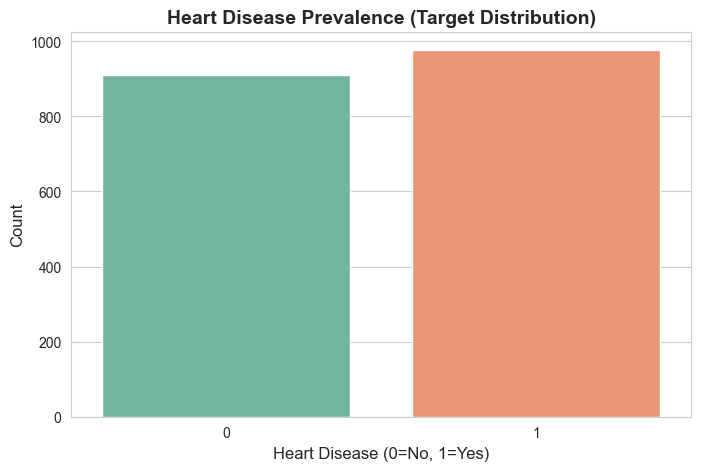


Disease Prevalence: 51.75%


In [5]:
# Analyze target distribution
target_counts = df['target'].value_counts()
print("Target Distribution:")
print(target_counts)

# Create visualization
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Heart Disease Prevalence (Target Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Heart Disease (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.savefig('../visuals/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nDisease Prevalence: {(target_counts[1] / len(df) * 100):.2f}%")

## 5. Age vs Disease Risk Analysis

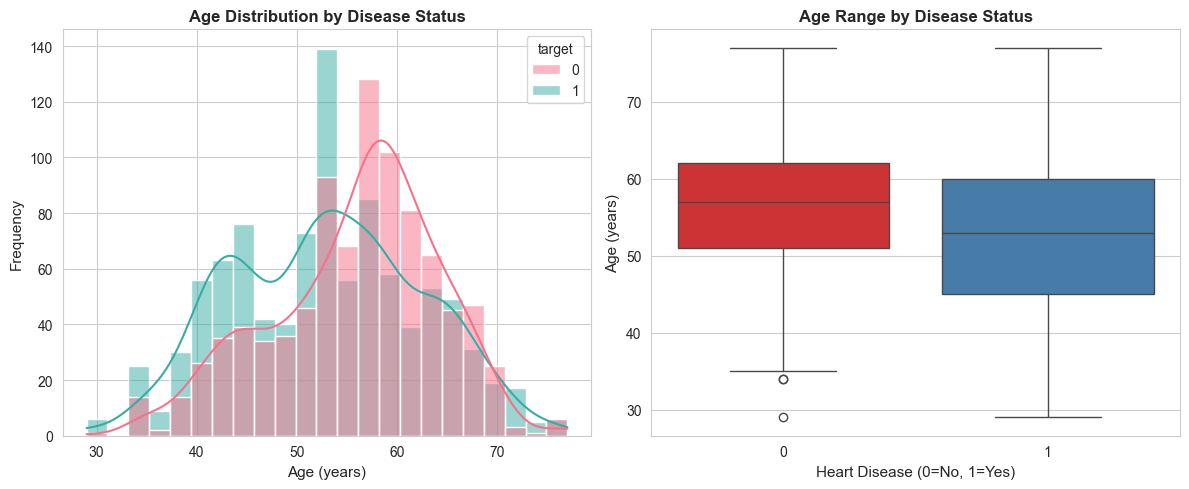

Age Statistics by Disease Status:
        count       mean       std   min   25%   50%   75%   max
target                                                          
0       911.0  55.880351  8.332246  29.0  51.0  57.0  62.0  77.0
1       977.0  52.931423  9.514355  29.0  45.0  53.0  60.0  77.0


In [6]:
# Age distribution by disease status
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='age', hue='target', kde=True, palette='husl')
plt.title('Age Distribution by Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Age (years)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='target', y='age', palette='Set1')
plt.title('Age Range by Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Heart Disease (0=No, 1=Yes)', fontsize=11)
plt.ylabel('Age (years)', fontsize=11)

plt.tight_layout()
plt.savefig('../visuals/age_vs_disease.png', dpi=300, bbox_inches='tight')
plt.show()

print("Age Statistics by Disease Status:")
print(df.groupby('target')['age'].describe())

## 6. Gender-based Risk Analysis

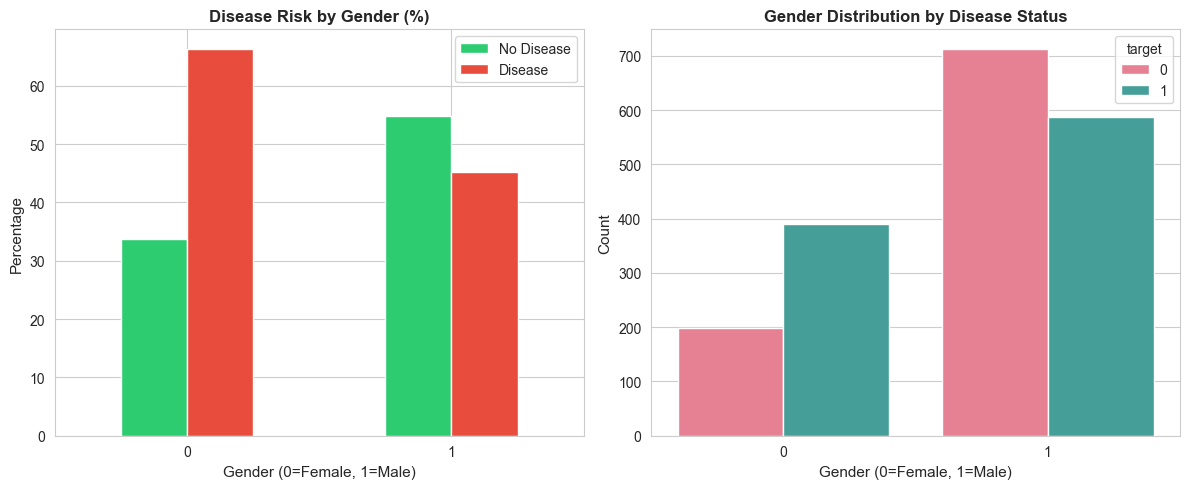

Gender vs Disease Cross-tabulation:
target    0    1   All
sex                   
0       198  390   588
1       713  587  1300
All     911  977  1888


In [7]:
# Gender vs disease risk
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
gender_disease = pd.crosstab(df['sex'], df['target'], normalize='index') * 100
gender_disease.plot(kind='bar', ax=plt.gca(), color=['#2ecc71', '#e74c3c'])
plt.title('Disease Risk by Gender (%)', fontsize=12, fontweight='bold')
plt.xlabel('Gender (0=Female, 1=Male)', fontsize=11)
plt.ylabel('Percentage', fontsize=11)
plt.legend(['No Disease', 'Disease'], loc='upper right')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='sex', hue='target', palette='husl')
plt.title('Gender Distribution by Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Gender (0=Female, 1=Male)', fontsize=11)
plt.ylabel('Count', fontsize=11)

plt.tight_layout()
plt.savefig('../visuals/gender_risk.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gender vs Disease Cross-tabulation:")
print(pd.crosstab(df['sex'], df['target'], margins=True))

## 7. Cholesterol Analysis

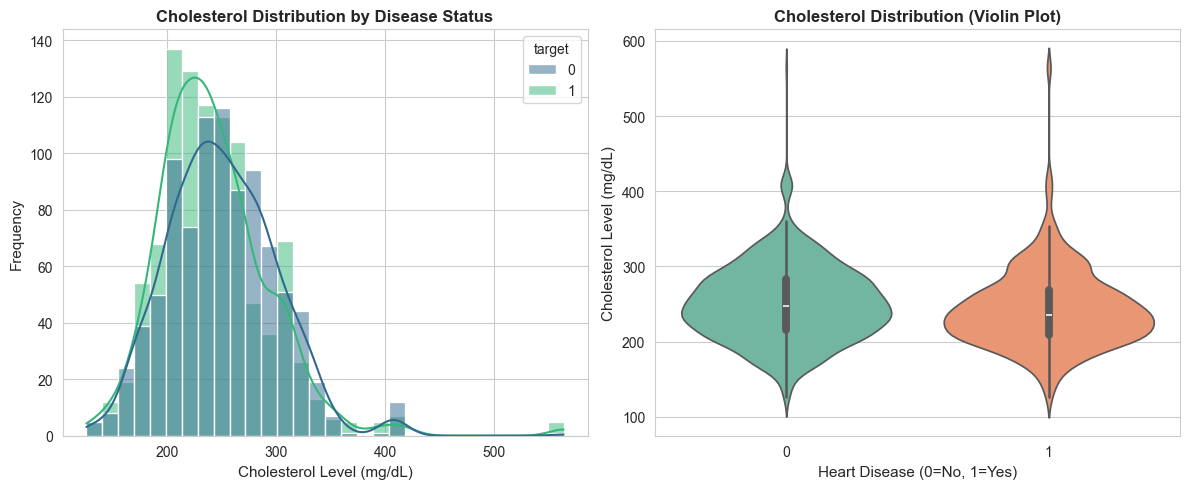

Cholesterol Statistics:
        count        mean        std    min    25%    50%    75%    max
target                                                                 
0       911.0  250.680571  50.122882  126.0  216.0  248.0  283.0  564.0
1       977.0  243.288639  52.733794  126.0  209.0  235.0  269.0  564.0


In [8]:
# Cholesterol distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='chol', hue='target', kde=True, palette='viridis', bins=30)
plt.title('Cholesterol Distribution by Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Cholesterol Level (mg/dL)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)

plt.subplot(1, 2, 2)
sns.violinplot(data=df, x='target', y='chol', palette='Set2')
plt.title('Cholesterol Distribution (Violin Plot)', fontsize=12, fontweight='bold')
plt.xlabel('Heart Disease (0=No, 1=Yes)', fontsize=11)
plt.ylabel('Cholesterol Level (mg/dL)', fontsize=11)

plt.tight_layout()
plt.savefig('../visuals/cholesterol_dist.png', dpi=300, bbox_inches='tight')
plt.show()

print("Cholesterol Statistics:")
print(df.groupby('target')['chol'].describe())

## 8. Chest Pain Type Analysis

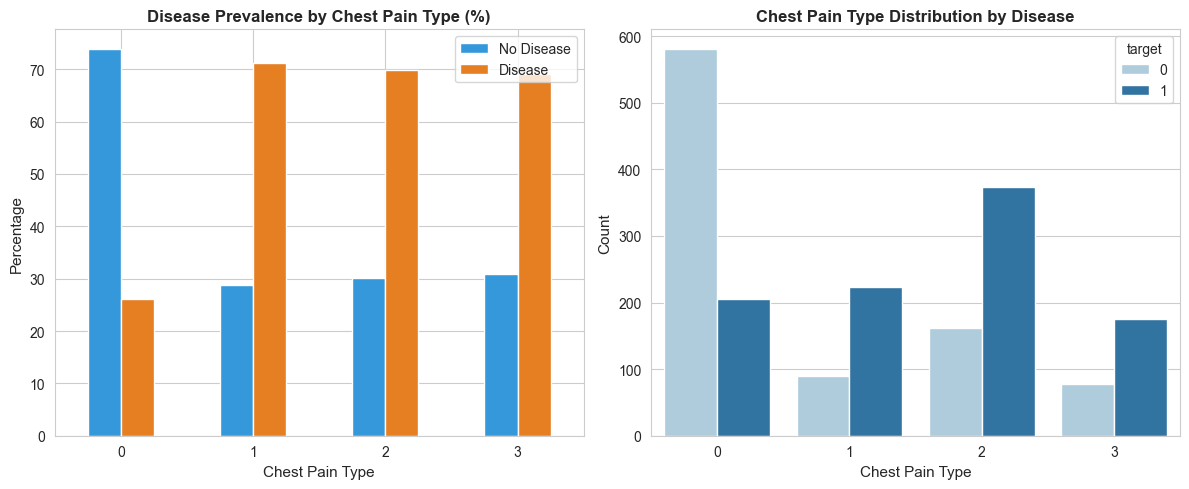

Chest Pain Type vs Disease:
target    0    1   All
cp                    
0       581  205   786
1        90  223   313
2       162  374   536
3        78  175   253
All     911  977  1888


In [9]:
# Chest pain type vs disease
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cp_disease = pd.crosstab(df['cp'], df['target'], normalize='index') * 100
cp_disease.plot(kind='bar', ax=plt.gca(), color=['#3498db', '#e67e22'])
plt.title('Disease Prevalence by Chest Pain Type (%)', fontsize=12, fontweight='bold')
plt.xlabel('Chest Pain Type', fontsize=11)
plt.ylabel('Percentage', fontsize=11)
plt.legend(['No Disease', 'Disease'], loc='upper right')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='cp', hue='target', palette='Paired')
plt.title('Chest Pain Type Distribution by Disease', fontsize=12, fontweight='bold')
plt.xlabel('Chest Pain Type', fontsize=11)
plt.ylabel('Count', fontsize=11)

plt.tight_layout()
plt.savefig('../visuals/chest_pain_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chest Pain Type vs Disease:")
print(pd.crosstab(df['cp'], df['target'], margins=True))

## 9. Correlation Heatmap

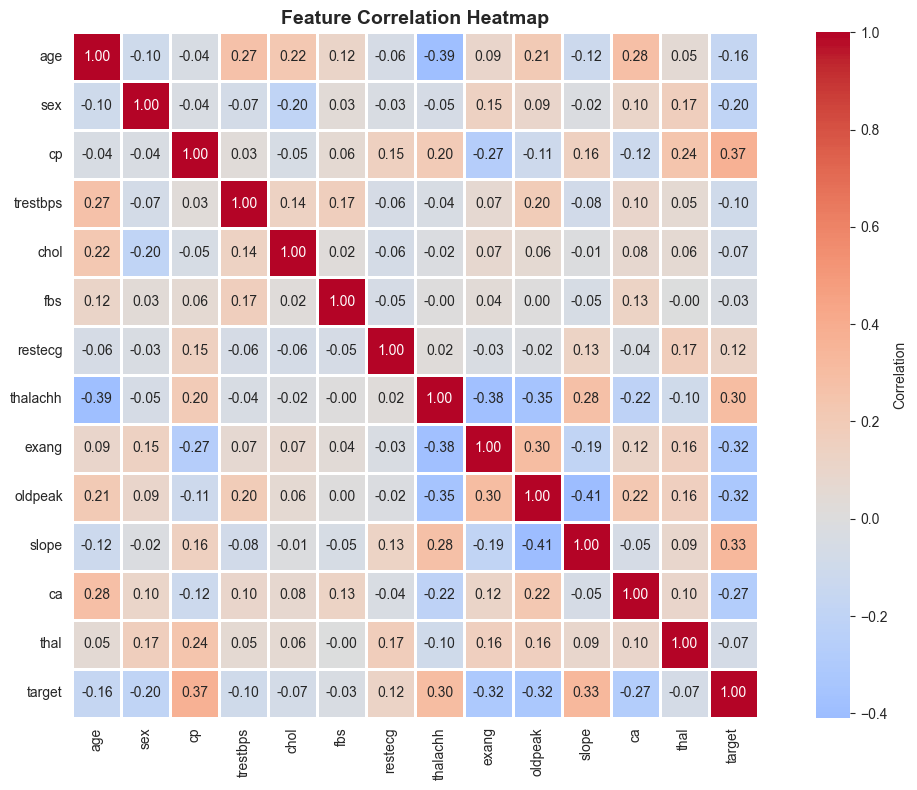


Correlation with Target (Heart Disease):
target      1.000000
cp          0.371258
slope       0.333837
thalachh    0.298795
restecg     0.123289
fbs        -0.032491
thal       -0.067322
chol       -0.071589
trestbps   -0.095875
age        -0.162303
sex        -0.196214
ca         -0.273105
exang      -0.315084
oldpeak    -0.315629
Name: target, dtype: float64


In [10]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Display correlations with target
print("\nCorrelation with Target (Heart Disease):")
print(correlation_matrix['target'].sort_values(ascending=False))

## 10. Key Insights Summary

In [11]:
print("=" * 70)
print("KEY INSIGHTS FROM HEART DISEASE ANALYSIS")
print("=" * 70)

print(f"\n1. OVERALL STATISTICS:")
print(f"   - Total Patients: {len(df)}")
print(f"   - Patients with Heart Disease: {(df['target'].sum())} ({(df['target'].mean() * 100):.1f}%)")
print(f"   - Patients without Disease: {(len(df) - df['target'].sum())} ({((1 - df['target'].mean()) * 100):.1f}%)")

print(f"\n2. AGE INSIGHTS:")
print(f"   - Average Age (Disease): {df[df['target']==1]['age'].mean():.1f} years")
print(f"   - Average Age (No Disease): {df[df['target']==0]['age'].mean():.1f} years")
print(f"   - Age Difference: {(df[df['target']==1]['age'].mean() - df[df['target']==0]['age'].mean()):.1f} years")

print(f"\n3. GENDER INSIGHTS:")
disease_by_gender = df.groupby('sex')['target'].agg(['sum', 'count', 'mean'])
print(f"   - Female Disease Rate: {(disease_by_gender.loc[0, 'mean'] * 100):.1f}%")
print(f"   - Male Disease Rate: {(disease_by_gender.loc[1, 'mean'] * 100):.1f}%")

print(f"\n4. CHOLESTEROL INSIGHTS:")
print(f"   - Avg Cholesterol (Disease): {df[df['target']==1]['chol'].mean():.1f} mg/dL")
print(f"   - Avg Cholesterol (No Disease): {df[df['target']==0]['chol'].mean():.1f} mg/dL")

print(f"\n5. CHEST PAIN TYPE:")
print(f"   - Most Common Type with Disease: Type {df[df['target']==1]['cp'].mode()[0]}")

print("\n" + "=" * 70)

KEY INSIGHTS FROM HEART DISEASE ANALYSIS

1. OVERALL STATISTICS:
   - Total Patients: 1888
   - Patients with Heart Disease: 977 (51.7%)
   - Patients without Disease: 911 (48.3%)

2. AGE INSIGHTS:
   - Average Age (Disease): 52.9 years
   - Average Age (No Disease): 55.9 years
   - Age Difference: -2.9 years

3. GENDER INSIGHTS:
   - Female Disease Rate: 66.3%
   - Male Disease Rate: 45.2%

4. CHOLESTEROL INSIGHTS:
   - Avg Cholesterol (Disease): 243.3 mg/dL
   - Avg Cholesterol (No Disease): 250.7 mg/dL

5. CHEST PAIN TYPE:
   - Most Common Type with Disease: Type 2

